In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from Pruning import *
from scipy.linalg import solve, qr
import numpy as np
from Plot import *
import random
import wandb

# Transform to tensor
dataset_transform = transforms.Compose([
    transforms.ToTensor(),                 
    #transforms.Normalize((0.1307,), (0.3081,))  # Normalization 
])

train_dataset = datasets.MNIST(
    root = "./data",      
    train = True,         
    download = True,      
    transform = dataset_transform
)

test_dataset = datasets.MNIST(
    root = "./data",
    train = False,        
    download = True,
    transform = dataset_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

<img src="nn4MNIST.png" alt="nn" width="600">

In [2]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("mps" if torch.mps.is_available() else "cpu")
#device = torch.device("cpu")

class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 5),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.model(x)
        return x
    

model2 = Model2().to(device)

# loss functiom & optimizer
loss_fun = nn.CrossEntropyLoss()
optimizer = optim.SGD(model2.parameters(), lr=0.1, momentum=0.9)

train_data_size = len(train_dataset)
test_data_size = len(test_dataset)

In [3]:
epoch = 1

for i in range(epoch):
    print("-------Epoch {}-------".format(i+1))
    # train
    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        outputs = model2(imgs)
        loss = loss_fun(outputs, targets)

        # optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # test
    total_test_loss = 0
    total_accuracy = 0
    wrong_indices = []
    base_idx = 0
    with torch.no_grad():
        for imgs, targets in test_loader:
            batch_size = targets.size(0)
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model2(imgs)

            loss0 = loss_fun(outputs, targets)
            total_test_loss = total_test_loss + loss0.item()

            accuracy = (outputs.argmax(1) == targets).sum().item()
            total_accuracy = total_accuracy + accuracy

            # Record indices of misclassified samples
            if i == epoch - 1:  # Only record for the last epoch
                wrong_in_batch = torch.where(outputs.argmax(1) != targets)[0]
                wrong_indices.extend((base_idx + wrong_in_batch).tolist())
                base_idx += batch_size


    print("Total loss in test set: {}".format(total_test_loss))
    print("Total accuracy in test set: {}".format(total_accuracy / len(test_dataset)))

print("Number of samples misclassified by the original model:", len(wrong_indices))

-------Epoch 1-------
Total loss in test set: 0.5805117059499025
Total accuracy in test set: 0.9821
Number of samples misclassified by the original model: 179


In [4]:
batch_list = list(train_loader)
X, _ = random.choice(batch_list)
X = X.to(device)

In [6]:
prune_info = {
    0: {"criterion": "keep_rank", "value": 0.7, "method": "StrongRRQR"},
    3: {"criterion": "tol", "value": 9, "method": "StrongRRQR"},
    7: {"criterion": "tol", "value": 5, "method": "StrongRRQR"},
}
params_new = prune_model(model2, X, prune_info)
pruned_model = load_pruned_model(model2, params_new)
flop = compute_total_flops(pruned_model.model, (1,28,28))
acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model, test_loader)

print()
print(f"Flop after pruning: {flop}")
print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 32 -> 22
-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 64 -> 26
-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of columns: 64 -> 22

Flop after pruning: 2511438

0.6931 3069


In [7]:
prune_info = {
    0: {"criterion": "keep_rank", "value": 0.9, "method": "StrongRRQR"},
    3: {"criterion": "keep_rank", "value": 0.9, "method": "StrongRRQR"},
    7: {"criterion": "keep_rank", "value": 0.8, "method": "StrongRRQR"},
}
params_new = prune_model(model2, X, prune_info)
pruned_model = load_pruned_model(model2, params_new)
flop = compute_total_flops(pruned_model.model, (1,28,28))

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model, test_loader)
print()
print(f"Flop after pruning: {flop}")
print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 32 -> 28
-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 64 -> 57
-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of columns: 64 -> 51

Flop after pruning: 6047247

0.9769 231


In [9]:
params_iter = iterative_pruning(model2, X, (1,28,28), 0.5, 0.8, "StrongRRQR")

pruned_model_iter = load_pruned_model(model2, params_iter)

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model_iter, test_loader)

print()
print(acc, len(wrong_samples_pruned))

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 64 -> 51

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 64 -> 51

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 32 -> 25

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 51 -> 40

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 40 -> 32

Flops after pruning: 7652672 -> 3366191

0.7824 2176


In [12]:
params_iter = iterative_pruning(model2, X, (1,28,28), 0.4, 0.95, "ARP")

pruned_model_iter = load_pruned_model(model2, params_iter)

acc, wrong_samples_pruned = evaluate_pruned_model(pruned_model_iter, test_loader)

print()
print(acc, len(wrong_samples_pruned)) 

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 64 -> 60

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 60 -> 57

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 57 -> 54

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 54 -> 51

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 64 -> 60

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 32 -> 30

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 60 -> 57

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 57 -> 54

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 51 -> 48

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 54 -> 51

-------Begin pruning-------
layer_idx: 0, layer_type: C

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 64 -> 48

-------Begin pruning-------
layer_idx: 7, layer_type: Linear
number of out_neurons: 64 -> 48

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 32 -> 24

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 48 -> 36

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 24 -> 18

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 18 -> 13

-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 36 -> 27

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 13 -> 9

-------Begin pruning-------
layer_idx: 0, layer_type: Conv2d
number of out_channels: 9 -> 6

Flops after pruning: 7652672 -> 744048
-------Begin pruning-------
layer_idx: 3, layer_type: Conv2d
number of out_channels: 64 -> 48

-------Begin pr

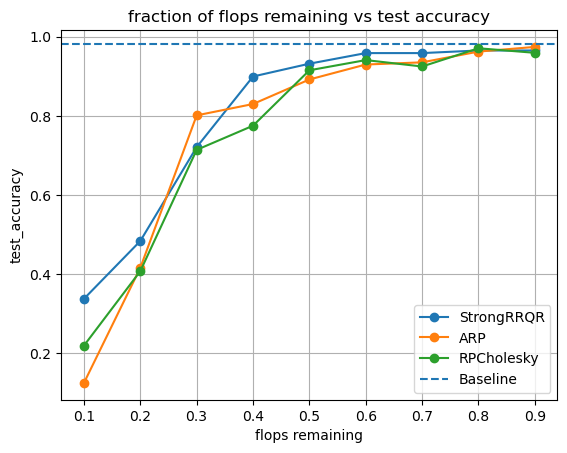

In [13]:
rho = np.linspace(0.1, 0.9, 9)
base_acc = total_accuracy / test_data_size
methods = ["StrongRRQR", "ARP", "RPCholesky"]
all_accs = []
for method in methods:
    accs = []
    for r in rho:
        params_iter = iterative_pruning(model2, X, (1,28,28), r, 0.75, method)
        pruned_model_iter = load_pruned_model(model2, params_iter)
        acc, _ = evaluate_pruned_model(pruned_model_iter, test_loader)
        accs.append(acc)
    all_accs.append(accs)

plot_pruning_curve(base_acc, rho, all_accs, methods,
                   title="fraction of flops remaining vs test accuracy")